# Import Libraries

In [4]:
import pandas as pd
import numpy as np
import math
import matplotlib.pyplot as plt
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

# Read Data

In [12]:
df = pd.read_csv('CICIDS2018_top_26.csv')
df.shape

CPU times: total: 4.66 s
Wall time: 5.52 s


(748068, 26)

In [14]:
df.head(3)

,Init Fwd Win Byts,Init Bwd Win Byts,Flow IAT Std,Fwd Seg Size Min,Dst Port,Fwd Header Len,Bwd Header Len,Fwd Act Data Pkts,Flow IAT Max,Flow IAT Mean,...,ECE Flag Cnt,Flow Duration,Fwd Pkt Len Max,TotLen Fwd Pkts,Active Mean,Down/Up Ratio,Fwd URG Flags,Protocol,Flow Byts/s,Label
0,8192,221,1.862841e+06,20,80,112,72,1,4939097,7.148869e+05,...,1,5004208,646,646,0,0,0,6,201.830140,Brute Force -Web
1,-1,-1,1.534511e+07,8,500,48,0,5,41990274,1.789594e+07,...,0,89479715,500,3000,4000276,0,0,17,33.527152,Brute Force -Web
2,2051,-1,0.000000e+00,20,80,40,0,0,11,1.100000e+01,...,0,11,0,0,0,0,0,6,0.000000,Brute Force -Web


In [16]:
df.duplicated().sum()

0

# Model Training

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

### Split Train-Test

In [22]:
X = df.drop(columns=['Label'])
y = df['Label']

le = LabelEncoder()
y_encoded = le.fit_transform(y)

X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded)

### Handling Class Imbalance (SMOTE)

In [26]:
%%time
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42, k_neighbors=3)
X_train_resampled, y_train_resampled = sm.fit_resample(X_train, y_train)

CPU times: total: 1min 38s
Wall time: 37.1 s


### Before and After SMOTE

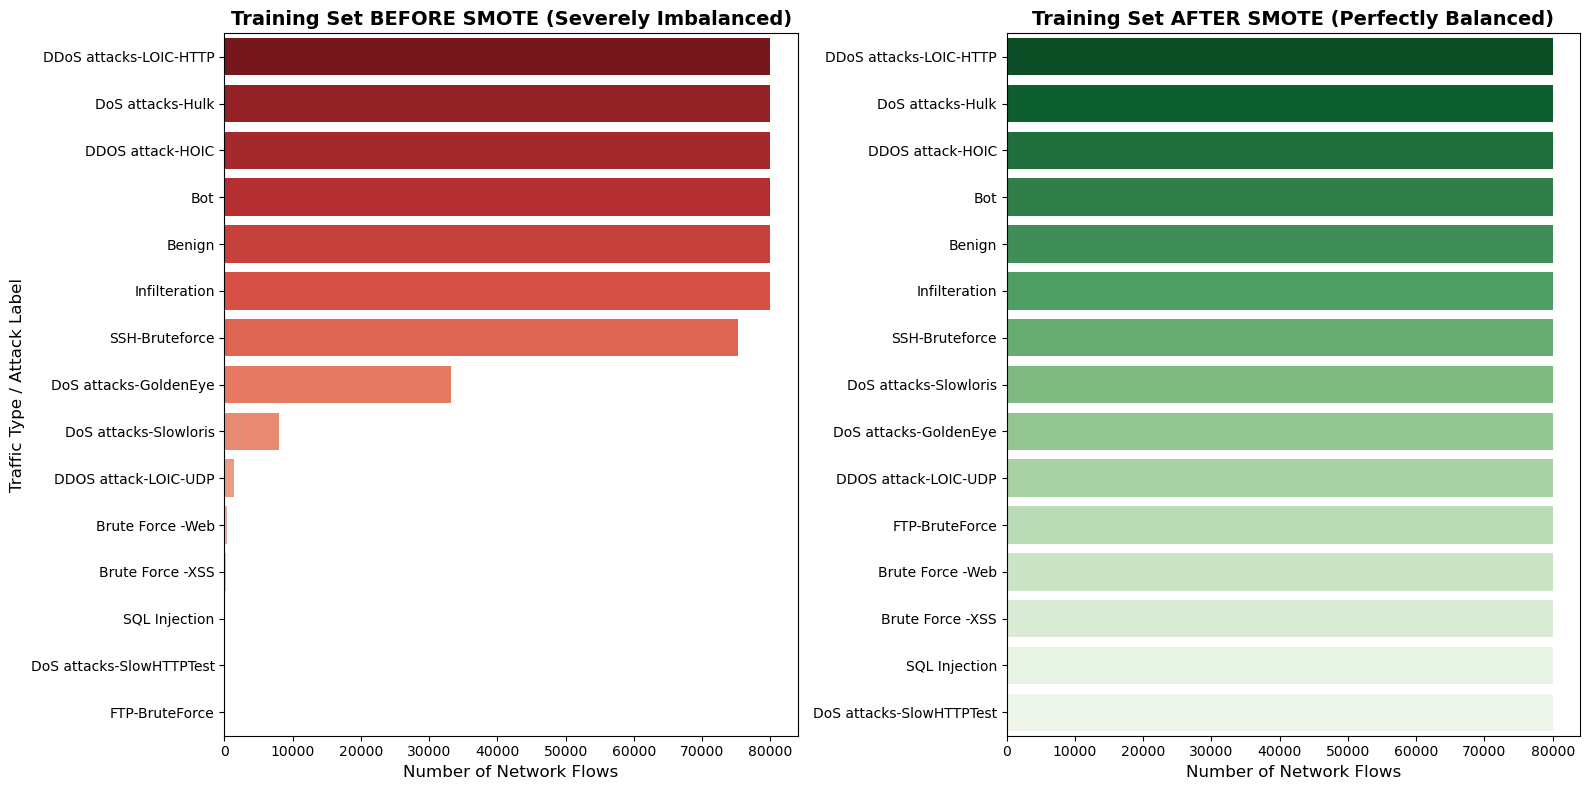

In [29]:
y_train_names = le.inverse_transform(y_train)
y_train_resampled_names = le.inverse_transform(y_train_resampled)

# Create dataframes to easily count the values
df_before = pd.DataFrame({'Attack Type': y_train_names})
df_after = pd.DataFrame({'Attack Type': y_train_resampled_names})

# Count the occurrences and sort them
counts_before = df_before['Attack Type'].value_counts().reset_index()
counts_before.columns = ['Attack Type', 'Count']

counts_after = df_after['Attack Type'].value_counts().reset_index()
counts_after.columns = ['Attack Type', 'Count']

fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=False)

# --- Subplot 1: Before SMOTE ---
sns.barplot(
    data=counts_before, 
    x='Count', 
    y='Attack Type', 
    ax=axes[0], 
    palette='Reds_r' 
)
axes[0].set_title('Training Set BEFORE SMOTE (Severely Imbalanced)', fontsize=14, weight='bold')
axes[0].set_xlabel('Number of Network Flows', fontsize=12)
axes[0].set_ylabel('Traffic Type / Attack Label', fontsize=12)

# --- Subplot 2: After SMOTE ---
sns.barplot(
    data=counts_after, 
    x='Count', 
    y='Attack Type', 
    ax=axes[1], 
    palette='Greens_r'
)
axes[1].set_title('Training Set AFTER SMOTE (Perfectly Balanced)', fontsize=14, weight='bold')
axes[1].set_xlabel('Number of Network Flows', fontsize=12)
axes[1].set_ylabel('') 

plt.tight_layout()
plt.savefig("SMOTE.png", dpi=300)
plt.show()

### Train the Model

In [32]:
%%time
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf.fit(X_train_resampled, y_train_resampled);

CPU times: total: 21min 19s
Wall time: 4min 27s


### Evaluate The Model

In [35]:
for name, model in [('Random Forest', rf)]:
    y_pred = model.predict(X_test)
    print(f"\n{'='*40}")
    print(f"{name}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))


Random Forest
                          precision    recall  f1-score   support

                  Benign       0.78      0.76      0.77     20000
                     Bot       1.00      1.00      1.00     20000
        Brute Force -Web       0.85      0.94      0.89       111
        Brute Force -XSS       1.00      0.98      0.99        45
        DDOS attack-HOIC       1.00      1.00      1.00     20000
    DDOS attack-LOIC-UDP       0.95      1.00      0.98       346
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00     20000
   DoS attacks-GoldenEye       1.00      1.00      1.00      8281
        DoS attacks-Hulk       1.00      1.00      1.00     20000
DoS attacks-SlowHTTPTest       0.12      0.09      0.11        11
   DoS attacks-Slowloris       1.00      1.00      1.00      1982
          FTP-BruteForce       0.31      0.36      0.33        11
           Infilteration       0.77      0.79      0.78     20000
           SQL Injection       0.55      0.71      0.62     

### Confusion Matrix

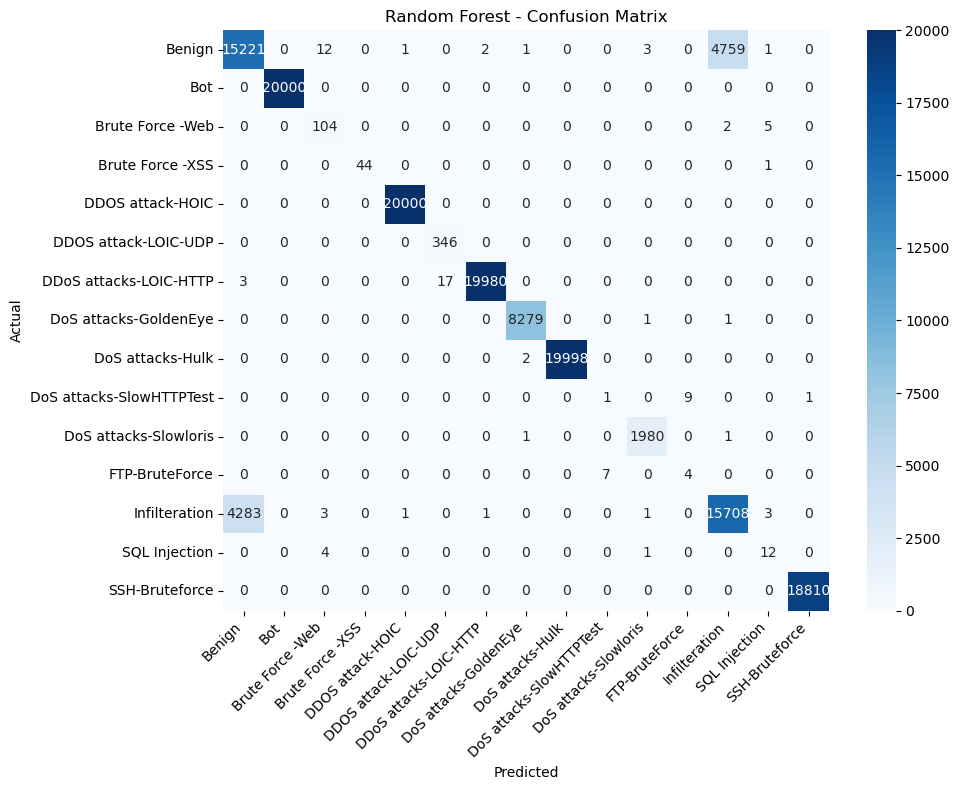

In [38]:
plt.figure(figsize=(10, 8))

cm = confusion_matrix(y_test, rf.predict(X_test))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')

plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Hyperparameter Tuning

In [41]:
from sklearn.model_selection import RandomizedSearchCV
import time

### Define Search Space

In [44]:
param_dist = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}

### RandomizedSearch

In [47]:
rf_base = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

rf_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=2
)

start = time.time()
rf_search.fit(X_train, y_train)
elapsed = (time.time() - start) / 60

print(f"Done in {elapsed:.1f} minutes")
print(f"Best params: {rf_search.best_params_}")
print(f"Best macro F1 (CV): {rf_search.best_score_:.4f}")

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Done in 95.9 minutes
Best params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': None}
Best macro F1 (CV): 0.8404


### Evaluate Tuned Model

In [50]:
best_rf = rf_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test)

print(classification_report(
    y_test, y_pred_tuned,
    target_names=le.classes_
))

                          precision    recall  f1-score   support

                  Benign       0.80      0.76      0.78     20000
                     Bot       1.00      1.00      1.00     20000
        Brute Force -Web       0.89      0.91      0.90       111
        Brute Force -XSS       1.00      0.96      0.98        45
        DDOS attack-HOIC       1.00      1.00      1.00     20000
    DDOS attack-LOIC-UDP       0.95      1.00      0.98       346
  DDoS attacks-LOIC-HTTP       1.00      1.00      1.00     20000
   DoS attacks-GoldenEye       1.00      1.00      1.00      8281
        DoS attacks-Hulk       1.00      1.00      1.00     20000
DoS attacks-SlowHTTPTest       0.12      0.09      0.11        11
   DoS attacks-Slowloris       1.00      1.00      1.00      1982
          FTP-BruteForce       0.31      0.36      0.33        11
           Infilteration       0.77      0.81      0.79     20000
           SQL Injection       0.60      0.88      0.71        17
         

### Confusion Matrix after RandomizedSearch

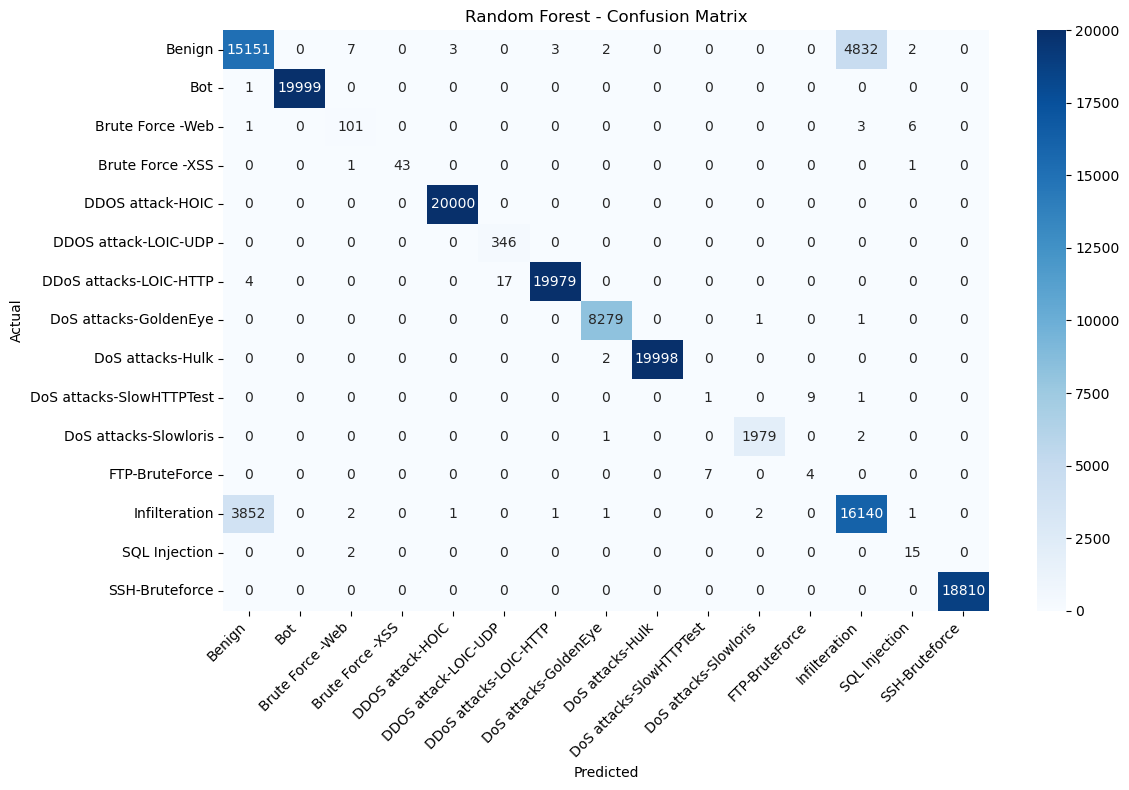

In [65]:
plt.figure(figsize=(12, 8))

cm = confusion_matrix(y_test, best_rf.predict(X_test))

sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap='Blues')

plt.title('Random Forest - Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.savefig('RF_Confusion_Matrix.png', dpi=400)
plt.show()

### Save the Best Model

In [56]:
import pickle

with open('RF_model.pkl', 'wb') as f:
    pickle.dump(best_rf, f)

print("Model saved.")

Model saved.


### Save the Label encoder for XGBoost

In [69]:
import pickle

with open('RF_label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("RF Label Encoder saved.")

RF Label Encoder saved.


### Test the saved model on real data 

In [12]:
import pickle
import joblib
from tensorflow.keras.models import load_model


# Load real dataset
df_real = pd.read_csv('CICIDS2018_10Percent.csv')

# Clean column names from leading/trailing spaces)
df_real.columns = df_real.columns.str.strip()

# Select the same 26 columns used in training
selected_columns = ['Init Fwd Win Byts', 'Init Bwd Win Byts', 'Flow IAT Std',
       'Fwd Seg Size Min', 'Dst Port', 'Fwd Header Len', 'Bwd Header Len',
       'Fwd Act Data Pkts', 'Flow IAT Max', 'Flow IAT Mean', 'Fwd Pkts/s',
       'Flow Pkts/s', 'TotLen Bwd Pkts', 'Pkt Len Max', 'Bwd IAT Mean',
       'RST Flag Cnt', 'ECE Flag Cnt', 'Flow Duration', 'Fwd Pkt Len Max',
       'TotLen Fwd Pkts', 'Active Mean', 'Down/Up Ratio', 'Fwd URG Flags',
       'Protocol', 'Flow Byts/s', 'Label']

df_real = df_real[selected_columns]

X_real = df_real.drop(columns=['Label'])
y_real_raw = df_real['Label']

print("Real data shape:", X_real.shape)


# Replace infinite values with 0 
inf_count = np.isinf(X_real.values).sum()
print("Infinite values found:", inf_count)

X_real = X_real.replace([np.inf, -np.inf], 0)

# Just in case there are also genuine NaNs not from inf, fill those with 0 too
nan_count = X_real.isna().sum().sum()
print("NaN values found:", nan_count)
X_real = X_real.fillna(0)

print("Real data shape after cleaning:", X_real.shape)
print("Class distribution:\n", y_real_raw.value_counts())

# ==============================
# RANDOM FOREST evaluation
# ==============================
with open('RF_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)
with open('RF_label_encoder.pkl', 'rb') as f:
    rf_le = pickle.load(f)

y_real_rf = rf_le.transform(y_real_raw)
rf_preds = rf_model.predict(X_real)

print("\n========== RANDOM FOREST ==========")
print(classification_report(y_real_rf, rf_preds, target_names=rf_le.classes_, zero_division=0))

Real data shape: (1198955, 25)
Infinite values found: 10257
NaN values found: 4515
Real data shape after cleaning: (1198955, 25)
Class distribution:
 Label
Benign                      1063690
DDoS attacks-LOIC-HTTP        57536
DDOS attack-HOIC              19886
DoS attacks-Hulk              14520
Bot                           14454
Infilteration                 14061
SSH-Bruteforce                 9405
DoS attacks-GoldenEye          4141
DoS attacks-Slowloris           991
DDOS attack-LOIC-UDP            173
Brute Force -Web                 56
Brute Force -XSS                 23
SQL Injection                     8
DoS attacks-SlowHTTPTest          6
FTP-BruteForce                    5
Name: count, dtype: int64

========== RANDOM FOREST ==========
                          precision    recall  f1-score   support

                  Benign       1.00      0.76      0.86   1063690
                     Bot       1.00      1.00      1.00     14454
        Brute Force -Web       0.10      1